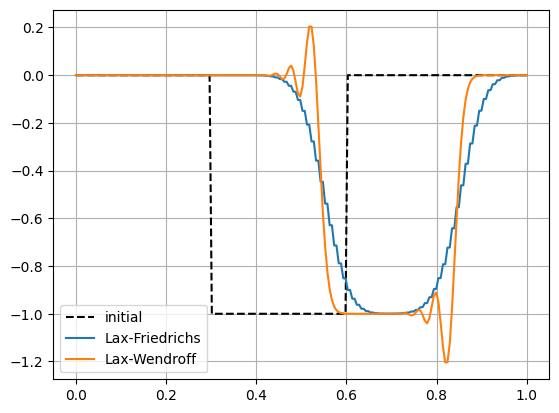

In [4]:
import numpy as np
import matplotlib.pyplot as plt

nx = 200
x = np.linspace(0, 1, nx)
dx = x[1] - x[0]
c = 1.0
dt = 0.5 * dx / c   
nt = 100

u0 = np.where((x > 0.3) & (x < 0.6), -1.0, 0.0)

u_lf = u0.copy()
u_lw = u0.copy()

for _ in range(nt):
    u_lf_new = u_lf.copy()
    u_lw_new = u_lw.copy()

    for j in range(nx):
        jp = (j + 1) % nx   
        jm = (j - 1) % nx

        u_lf_new[j] = 0.5*(u_lf[jp] + u_lf[jm]) \
                      - 0.5*(c*dt/dx)*(u_lf[jp] - u_lf[jm])

        u_lw_new[j] = u_lw[j] \
                      - 0.5*(c*dt/dx)*(u_lw[jp] - u_lw[jm]) + \
                      0.5*(c*dt/dx)**2 * (u_lw[jp] - 2*u_lw[j] + u_lw[jm])

    u_lf = u_lf_new
    u_lw = u_lw_new

# plot
plt.plot(x, u0, 'k--', label='initial')
plt.plot(x, u_lf, label='Lax-Friedrichs')
plt.plot(x, u_lw, label='Lax-Wendroff')
plt.legend()
plt.grid()
plt.show()
